In [2]:
%load_ext autoreload
%autoreload 2

# Library/module imports
from matplotlib import pyplot as plt
import numpy as np
from dataclasses import asdict

from polarity.models import par3nd as pmodel
from polarity.utilities import figure_helper as fh
from polarity.utilities.metric_functions import polarity_measure, find_interface

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Example of establishment using default parameters (Fig. 5)

In [3]:
# Discretisation and initial conditions
initial_condition = pmodel.run_for_ss_initial_condition()
Nx = len(initial_condition) // 4
print(f"Initial condition: [J, M, A, P] = {initial_condition[[0, Nx, 2*Nx, 3*Nx]]}")

# Timings
tL = 120*60
output_freq = 10 # seconds (affects smoothness of the polarity and interface plots, but not the J/M/A/P plots)
store_times = np.linspace(0,tL,num = int(tL/output_freq)+1)

# Run to steady state (~15-20 seconds)
sol, setup = pmodel.run_model({
                        "t_eval": store_times,
                        "tL": tL, 
                        "initial_condition": initial_condition
                    })

Initial condition: [J, M, A, P] = [1.0192463  1.03009866 0.375326   0.01195164]


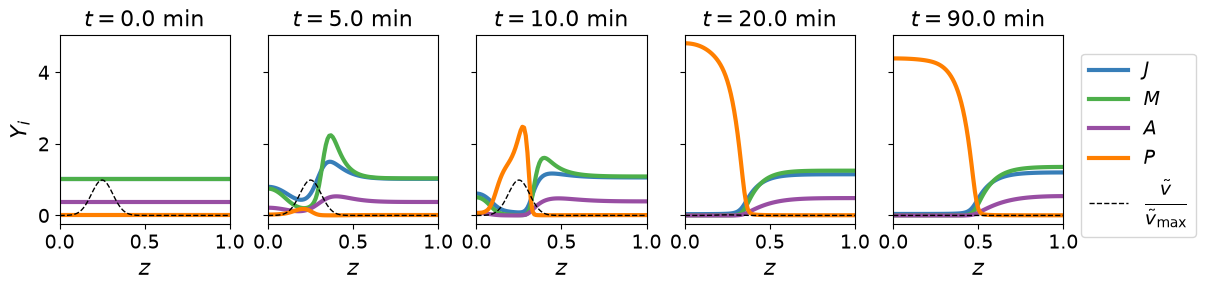

In [4]:
# Plot the profiles over time
plot_times = [mins*60 for mins in [0, 5, 10, 20, 90]]
fig, axs = plt.subplots(nrows=1, ncols=len(plot_times), 
                        sharey=True, layout='constrained', figsize=(fh.page_width_fig, 2.8))
for i, time in enumerate(plot_times):
    ti = [i for i, t in enumerate(store_times) if t == time]
    assert len(ti) == 1, f"Time {time} not found in store_times"
    ax = axs[i]
    fh.plot_time_point(ax, setup.X, sol.y[:, ti[0]], v_func = lambda x: setup.v_func(setup, x, time))
    ax.set_title(f"$t={time/60}$ min", fontsize=fh.font_size)
    if i != 0:
        ax.set_ylabel(None)
fh.add_shared_legend(fig, axs)
fig.savefig(fh.FIGURES_DIR / "establishment_example.pdf")

Final measures: polarity: 0.9838, interface: 0.4983


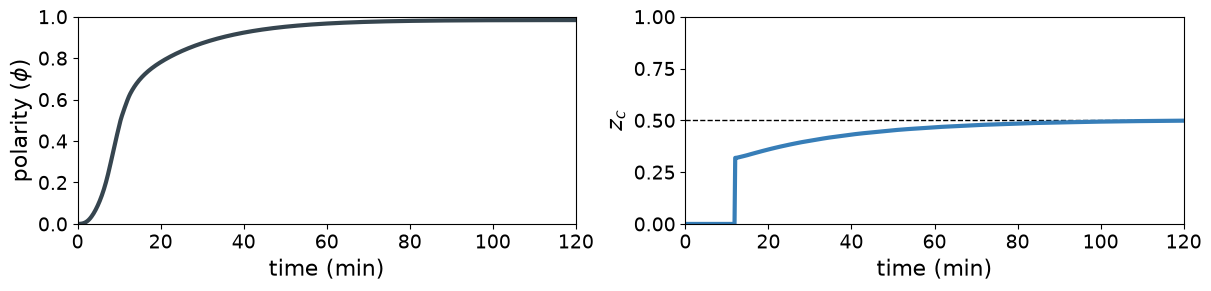

In [5]:
# Plot polarity and interface over time - Fig. 5b
fig, axs = plt.subplots(nrows=1, ncols=2, sharey=False, layout='constrained', figsize=(fh.page_width_fig, 2.8))

# Polarity measure
polarity = [polarity_measure(setup.X, sol.y[:, ti], setup.Species) for ti in range(np.shape(sol.y)[1])]
axs[0].plot(sol.t/60, polarity, color = fh.colours_map["polarity"])
axs[0].set_ylabel("polarity ($\\phi$)")
axs[0].set_xlabel("time (min)")
axs[0].tick_params(which="both")
axs[0].set_ylim(0,1)

# Apical-Basal Interface
interface = [find_interface(setup.X, sol.y[:, ti], setup.Species) for ti in range(np.shape(sol.y)[1])]
axs[1].axhline(y=0.5, color='k', linestyle='--', linewidth = 1)
axs[1].plot(sol.t/60, interface, color = fh.colours_map["J"])
axs[1].set_ylabel("$z_c$")
axs[1].set_xlabel("time (min)")
axs[1].set_ylim(0,0.5)
_ = axs[1].set_yticks([0, 0.25, 0.5, 0.75, 1])

print(f"Final measures: polarity: {polarity[-1]:.4f}, interface: {interface[-1]:.4f}")

fig.savefig(fh.FIGURES_DIR / "establishment_example_polarity.pdf")


MovieWriter ffmpeg unavailable; using Pillow instead.


Saving animation to /Users/cmil633/Documents/Active-Projects/Cell-Polarity/updated_repo/figures/establishment_example_animation.gif


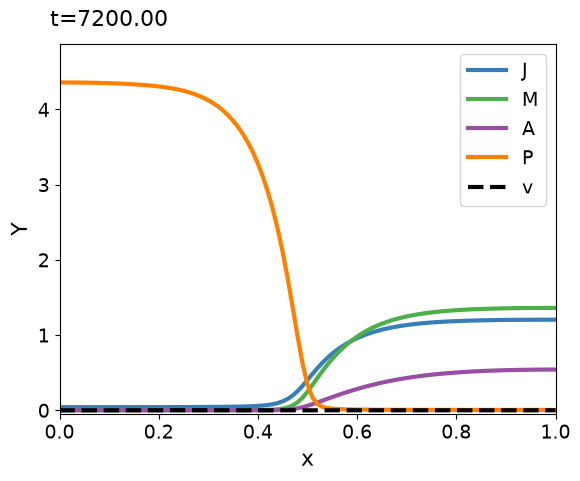

In [6]:
# Save an animation of the profiles over time
fh.animate_plot(sol, asdict(setup), save_file = fh.FIGURES_DIR / "establishment_example_animation")

## Polarisation metric examples (Fig. 3)

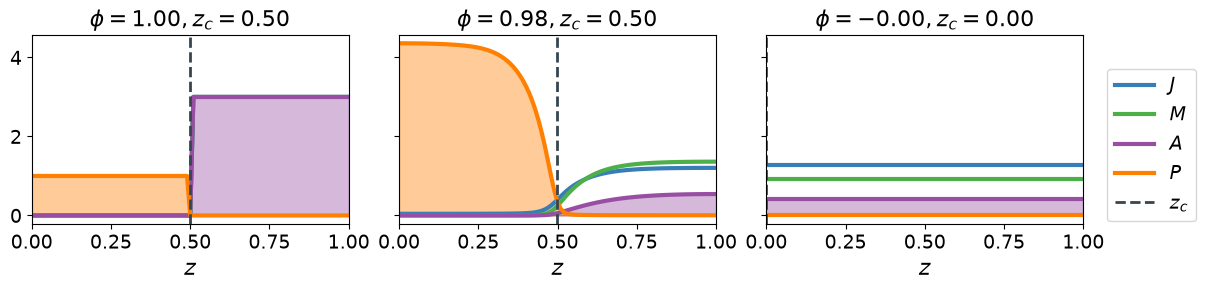

In [7]:
# Plot three example profiles
Nx = 101
hw = Nx // 2 # Half-width of the domain
# Idealised polarised examples
idealised = np.concatenate([ ([0]*(hw+1) + [3]*(hw)) * 3, \
                            [1]*(hw) + [0]*(hw+1) ])
# 'Realistic' example
realistic = sol.y[:, -1]
# Homogeneous examples
ss = [1.27666116, 0.93369654, 0.41724783, 0.01293095]
homogeneous = np.array([x for x in ss for i in range(Nx)])

# Stack solutions and plot
X = np.linspace(0, 1, Nx)
fig, axs = plt.subplots(nrows=1, ncols=3, 
                        sharey=True, layout='constrained', figsize=(fh.page_width_fig, 2.8))
for i, sol_i in enumerate([idealised, realistic, homogeneous]):
    ax = axs[i]
    df = fh.convert_output_to_pandas(X, sol_i)
    ax.fill_between(df.x, df.P, color=fh.colours_map["P"], alpha=0.4)
    ax.fill_between(df.x, df.A, color=fh.colours_map["A"], alpha=0.4)
    fh.plot_time_point(ax, X, sol_i)
    
    polarity = polarity_measure(X, sol_i, setup.Species)
    interface = find_interface(X, sol_i, setup.Species)
    ax.axvline(interface, linestyle="--", color=fh.colours_map["polarity"], linewidth=2, label = "$z_c$")
    ax.set_title(f"$\\phi={polarity:.2f}, z_c = {interface:.2f}$", fontsize=fh.font_size)
    
    ax.set_ylabel(None)
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
fh.add_shared_legend(fig, axs)

fig.savefig(fh.FIGURES_DIR / "metrics_diagram.pdf")
